# Tutorial for using plato_plotter

Lets start by importing the useful modules

In [1]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

Then let us import plato_plotter

In [2]:
import plato_plotter

plato_plotter will need to be in the same directory as "lops2_healpix9_footprint.fits", the file which contains the PLATO LOP.


Now to plot a star to see if it is in the southern PLATO LOP. Let's start by plotting the brightest star in the southern LOP: Canopus.

  Name        l              b        is_in_lop
             deg            deg                
------- -------------- -------------- ---------
Canopus 261.2121446764 -25.2922659096      True


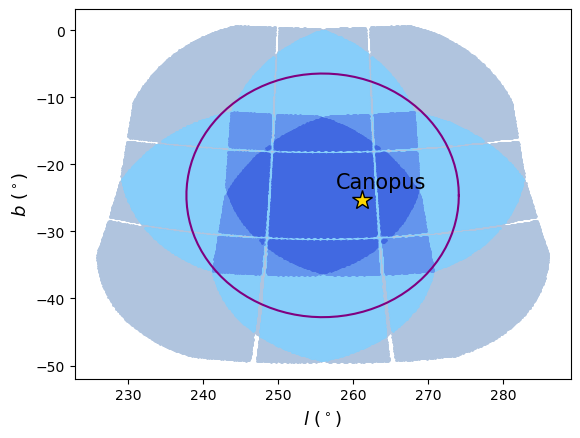

In [3]:
# Get the Galactic coordinates of Canopus from the Hipparcos
stars_canopus = SkyCoord(261.2121446764*u.deg, -25.2922659096*u.deg, frame = "galactic")
label_canopus = ["Canopus"]
plato_plotter.plot(stars_canopus, label_canopus)

So far so good. What about a star in the northern field of view? While the final observation strategy for PLATO could avoid the northern field entirely, plato_plotter currently also supports plotting the northern LOP.

Now lets take the northen CVZ star: χ Dra

 Name         l                  b          is_in_lop
             deg                deg                  
----- ------------------ ------------------ ---------
χ Dra 103.45727203571143 28.058369157839902      True


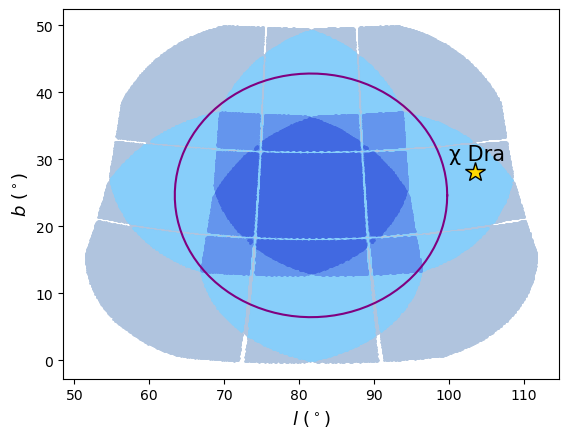

In [4]:
# This time we take the ICRS coordinate from Hipparcos
ra_dra, dec_dra = 275.25974572, 72.73369763
stars_dra = SkyCoord(ra_dra*u.deg, dec_dra*u.deg, frame = 'icrs')
label_dra = ["χ Dra"]

plato_plotter.plot(stars_dra, label_dra, LOP = "north")

Now, what about a star not within the southern LOP?

Let's look at one of my favourite star(s): α Cen

α Cen is not within LOPS2
 Name       l             b       is_in_lop
           deg           deg               
----- -------------- ------------ ---------
α Cen 315.7373239774 -0.687044998     False


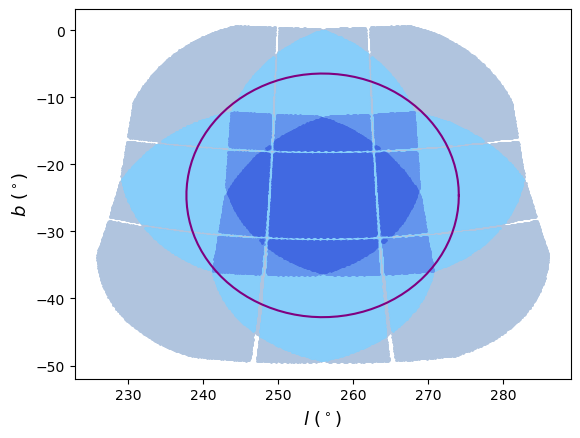

In [5]:
# Get the Galactic coordinates of α Cen from the Hipparcos
stars_cen = SkyCoord(315.7373239774*u.deg, -0.6870449980*u.deg, frame = "galactic")
label_cen = ["α Cen"]
plato_plotter.plot(stars_cen, label_cen)

What about multiple stars, such as cluster members, and can we save them? The answer is yes!


Here we use the CVZ open cluster NGC 1901 (Bernizzoni et al. in prep.)

In [6]:
import pandas as pd

# File kindly provided by Mara Bernizzoni
ngc1901 = pd.read_csv("ngc1901_ra_dec.csv")

In [7]:
tic_ngc1901, ra_ngc1901, dec_ngc1901 = ngc1901["TIC"].to_numpy(), ngc1901["ra"].to_numpy(), ngc1901["dec"].to_numpy()
# Prefer to save my stars with their ID in front
tic_ngc1901 = "TIC " + tic_ngc1901.astype(str)

# How many stars?
print(f"Number of stars in NGC 1901: {len(tic_ngc1901)} stars")

Number of stars in NGC 1901: 101 stars


That is a lot of stars. Luckily, we can just give one label to plato_plotter

     Name             l                   b          is_in_lop
                     deg                 deg                  
------------- ------------------ ------------------- ---------
TIC 179214959 278.68984239861913  -33.75895384541159      True
TIC 179213889 279.08268334940277  -33.67422303571043      True
TIC 389563650 278.13740956055256 -31.158716452605102      True
TIC 149447160  275.1117933305358 -31.919642979934732      True
TIC 149270613  275.2954587936992 -32.812051461236976      True
TIC 179637067 278.48861204238517  -33.23760357743953      True
TIC 179040399 278.76076733073717  -33.78899879274667      True
TIC 231744384  278.3234599208767 -34.231385147032654      True
 TIC 40346830 280.07834748732733  -34.22624731527027      True
          ...                ...                 ...       ...
TIC 358155214  287.1036835548624  -34.54650700887236     False
TIC 277185072  282.4354703635543 -31.381988522105466      True
TIC 179041083 279.03086660074035  -33.75409660139154   

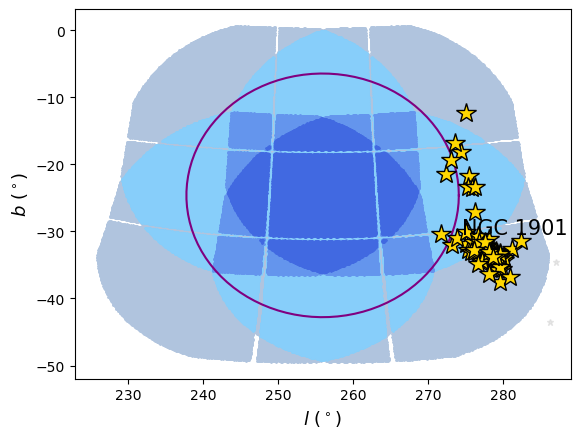

In [8]:
stars_ngc1901 = SkyCoord(ra_ngc1901*u.deg, dec_ngc1901*u.deg, frame = 'icrs')
label_ngc1901 = "NGC 1901"
save_name = "ngc1901_plato_stars.fits"
plato_plotter.plot(stars_ngc1901, tic_ngc1901, label_ngc1901, save_stars = save_name)